In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [6]:
df.shape

(74, 20)

In [7]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Text(0.5, 1.0, 'Number of Wins by Each Team')

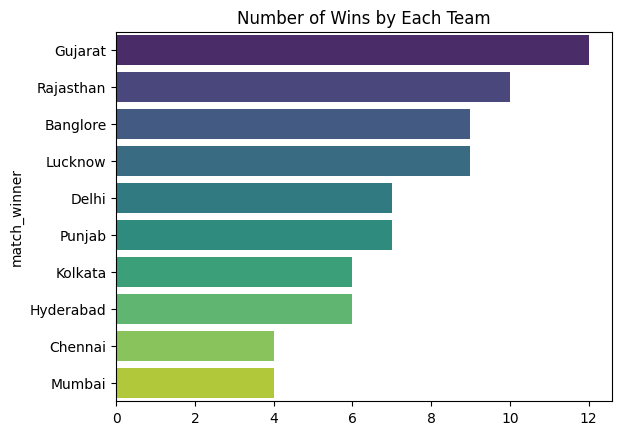

In [14]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y=match_wins.index, x=match_wins.values, palette='viridis')
plt.title('Number of Wins by Each Team')

Text(0.5, 1.0, 'Toss Decision Distribution')

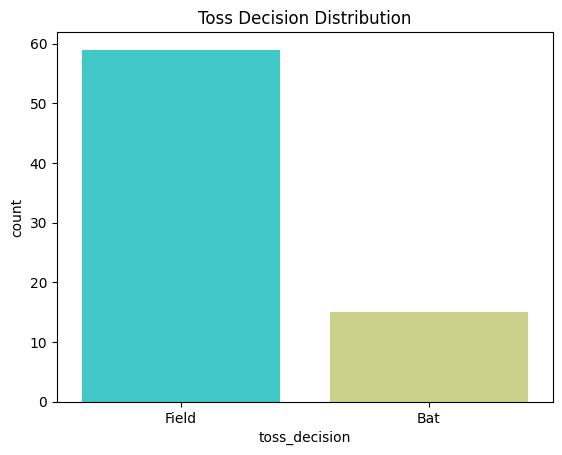

In [17]:
sns.countplot(x = df['toss_decision'], palette='rainbow')
plt.title('Toss Decision Distribution')

In [22]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count*100) / df.shape[0]
percentage.round(2)

np.float64(48.65)

Text(0.5, 1.0, 'Top 10 Players with Most Player of the Match Awards')

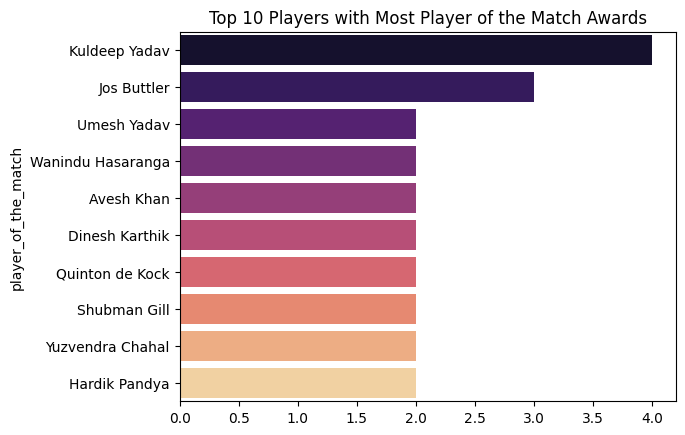

In [26]:
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=count.index, x=count.values, palette='magma')
plt.title('Top 10 Players with Most Player of the Match Awards')

<Axes: ylabel='top_scorer'>

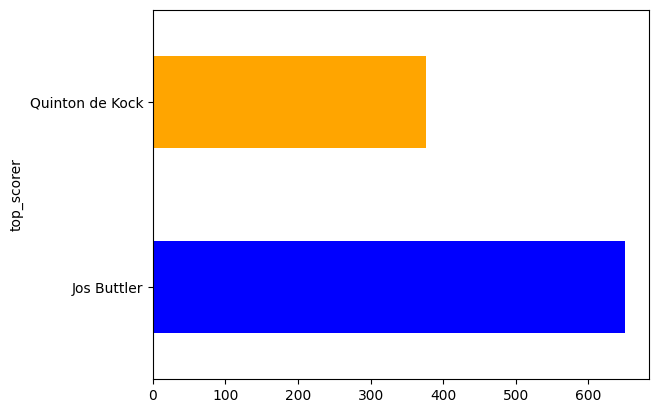

In [33]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high.plot(kind='barh', color=['blue', 'orange'])

<Axes: ylabel='best_bowling'>

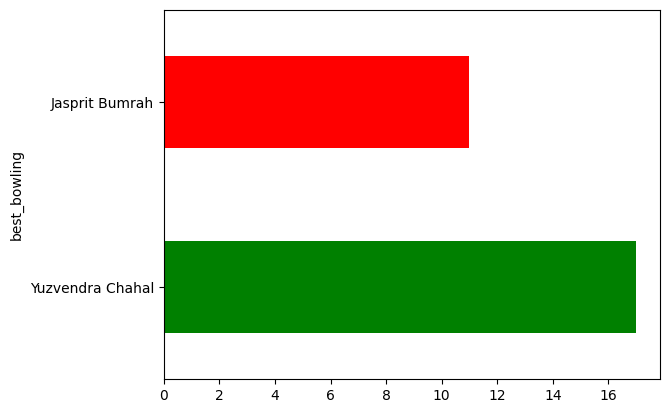

In [35]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowler = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(2)
top_bowler.plot(kind='barh', color=['green', 'red'])

In [39]:
import numpy as np
arr = np.array([2,3,4,6,7,8,9,12,13,16,17,23,25,27,34,37,201])

Q1 = np.percentile(arr, 25)
Q3 = np.percentile(arr, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = arr[(arr < lower_bound) | (arr > upper_bound)]
outliers


array([201])

In [13]:
import numpy as np
import scipy.stats as stats

sample = [172, 175, 168, 180, 169, 174, 171, 177, 173, 176]
population_mean = 170
population_std = 5
sample_mean = np.mean(sample)
sample_size = len(sample)
z_score = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:    print("Fail to reject the null hypothesis")

Reject the null hypothesis
